In [5]:
import anndata as ad
import numpy as np
import pandas as pd
import SDP_miRNA.dataset
import SDP_miRNA.optimization
import SDP_miRNA.optimization_MOSEK
import SDP_miRNA.correlation
import SDP_miRNA.simulation
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [6]:
rng = np.random.default_rng(867)

# Optimization scaling for large MRR model

M + R -> R

In [97]:
targets = 19
k_tx = 2
k_deg = 1
k_reg = 5

stoch_inp = np.zeros((2 + targets * 3, 1 + targets))
stoch_out = np.zeros((2 + targets * 3, 1 + targets))
rates = np.ones(2 + 3 * targets)

# miRNA tx and deg reactions
stoch_out[0, 0] = 1
rates[0] = k_tx
stoch_inp[1, 0] = 1
rates[1] = k_deg

for m in range(targets):

    r = 2 + 3 * m
    s = 1 + m

    # mRNA tx and deg reactions
    stoch_out[r, s] = 1
    rates[r] = k_tx
    stoch_inp[r + 1, s] = 1
    rates[r + 1] = k_deg

    # miRNA - mRNA interaction
    stoch_inp[r + 2, 0] = 1
    stoch_inp[r + 2, s] = 1
    stoch_out[r + 2, 0] = 1
    rates[r + 2] = k_reg

In [98]:
initial = None
tmax = 10100
tmin = 100
tint = 10
n = 1000

# run gillespie
path, path_times = SDP_miRNA.simulation.gillespie(stoch_inp, stoch_out, rates, initial, tmax)

In [99]:
# take samples at uniform time points
counts_OG = SDP_miRNA.simulation.uniform_time_samples(path, path_times, tmin=tmin, tmax=tmax, tint=tint, n=n)

In [100]:
# capture
mean_capture = 0.5
capture_shape = 30
capture_scale = (capture_shape / mean_capture) * (1 - mean_capture)

# sample capture
beta = rng.beta(capture_shape, capture_scale, size=n)

# downsample
counts_OG = counts_OG.astype(np.int64)
counts_OB = rng.binomial(counts_OG, beta[:, None])

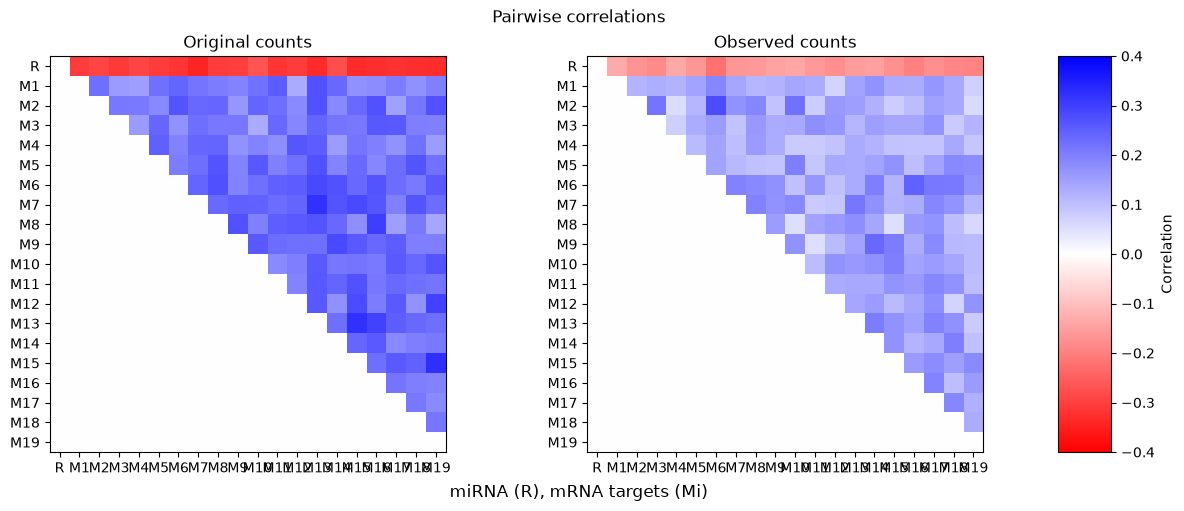

In [101]:
# compute original and observed data point correlations
correlation_matrix_original = np.corrcoef(counts_OG.T)
correlation_matrix_observed = np.corrcoef(counts_OB.T)

# remove redundant values
correlation_matrix_original[np.tril_indices(correlation_matrix_original.shape[0], k=0)] = 0
correlation_matrix_observed[np.tril_indices(correlation_matrix_observed.shape[0], k=0)] = 0

# display
RNA_labels = ["R"] + [f"M{i + 1}" for i in range(targets)]
cmap = LinearSegmentedColormap.from_list('a', ['red', 'white', 'blue'])
fig, axs = plt.subplots(1, 3, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 1, 0.1]}, constrained_layout=True)
im = axs[0].imshow(correlation_matrix_original, cmap=cmap, vmin=-0.4, vmax=0.4)
im = axs[1].imshow(correlation_matrix_observed, cmap=cmap, vmin=-0.4, vmax=0.4)
axs[0].set_title("Original counts")
axs[0].set_xticks(range(targets + 1))
axs[0].set_xticklabels(RNA_labels)
axs[0].set_yticks(range(targets + 1))
axs[0].set_yticklabels(RNA_labels)
axs[1].set_title("Observed counts")
axs[1].set_xticks(range(targets + 1))
axs[1].set_xticklabels(RNA_labels)
axs[1].set_yticks(range(targets + 1))
axs[1].set_yticklabels(RNA_labels)
fig.suptitle("Pairwise correlations")
fig.supxlabel("miRNA (R), mRNA targets (Mi)")
plt.colorbar(im, cax=axs[2], label="Correlation")
plt.show()

In [105]:
class GeneralBirthDeathOptimization(SDP_miRNA.optimization.Optimization):

    def __init__(self, dataset, targets, **kwargs):

        # preset settings
        constraints = SDP_miRNA.constraints.Constraint(
            moment_bounds=True,
            moment_matrices=True,
            moment_equations=True
        )
        reactions = [
            "1",
            "xs[0]"
        ]
        for i in range(targets):
            reactions += [
                "1",
                f"xs[{i + 1}]",
                f"xs[0] * xs[{i + 1}]"
            ]
        vrs = (stoch_out - stoch_inp)[:(2 + targets * 3), :(1 + targets)]
        db = 2
        R = len(reactions)
        S = 1 + targets
        U = []

        # default fixed rate
        if not ('rate_fixed' in kwargs.keys()):
            kwargs['rate_fixed'] = [(1, 1)]

        # initialize superclass
        super().__init__(
            dataset,
            constraints,
            reactions,
            vrs,
            db,
            R,
            S,
            U,
            **kwargs
        )

In [106]:
# construct dataset
data_SDP = SDP_miRNA.dataset.Dataset()

# duplicate full data (miRNA + mRNA) for easy indexing
data_SDP.construct_dataset_array(
    counts_OB,
    counts_OB,
    beta
)

In [107]:
# settings
max_opt_targets = 19
d = 3

# store results
time_dict = {}
cut_dict = {}
corr_dict = {}

for opt_targets in range(1, max_opt_targets + 1):

    # set gene queries
    gene_queries = [
        [[t for t in range(1 + opt_targets)], []]
    ]
    data_SDP.gene_queries = gene_queries
    data_SDP.total_gene_queries = len(gene_queries)

    # bootstrap
    data_SDP.bootstrap(d=d)

    # optimize
    BD_opt = GeneralBirthDeathOptimization(data_SDP, opt_targets, d=d)
    BD_opt.analyse_dataset()

    # construct recovered correlations
    correlation_matrix_recovered = np.zeros((1 + targets, 1 + targets))
    for i in range(1 + opt_targets):
        for j in range(i + 1, 1 + opt_targets):
            correlation_matrix_recovered[i, j] = BD_opt.compute_dataset_correlation(i, j)[0]

    time_dict[opt_targets] = BD_opt.result_dict[0]['time']
    cut_dict[opt_targets] = BD_opt.result_dict[0]['cuts']
    corr_dict[opt_targets] = correlation_matrix_recovered

100%|██████████| 1/1 [00:00<00:00, 26.39it/s]


Text(0.5, 0.98, 'Optimization scaling with species')

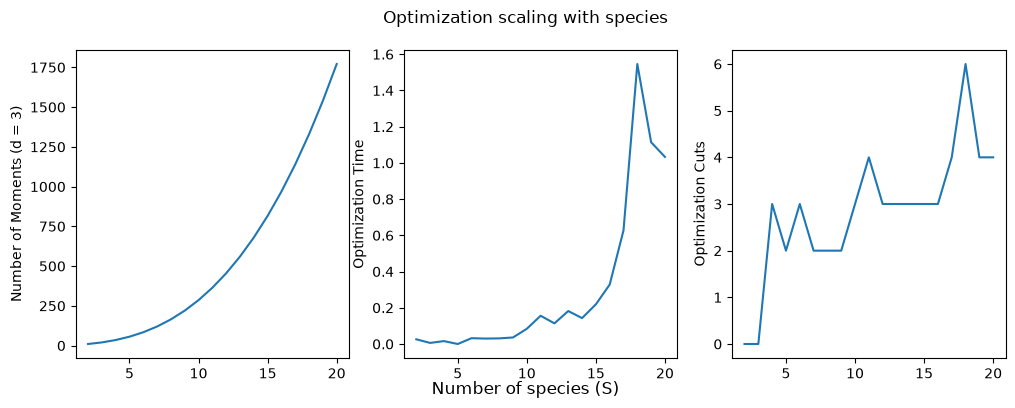

In [124]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
xs = [int(x) for x in range(2, max_opt_targets + 2)]
variables = [SDP_miRNA.utils.compute_Nd(S, d) for S in xs]
times = time_dict.values()
cuts = cut_dict.values()
axs[0].plot(xs, variables)
axs[0].set_ylabel("Number of Moments (d = 3)")
axs[1].plot(xs, times)
axs[1].set_ylabel("Optimization Time")
axs[2].plot(xs, cuts)
axs[2].set_ylabel("Optimization Cuts")
fig.supxlabel("Number of species (S)")
fig.suptitle("Optimization scaling with species")

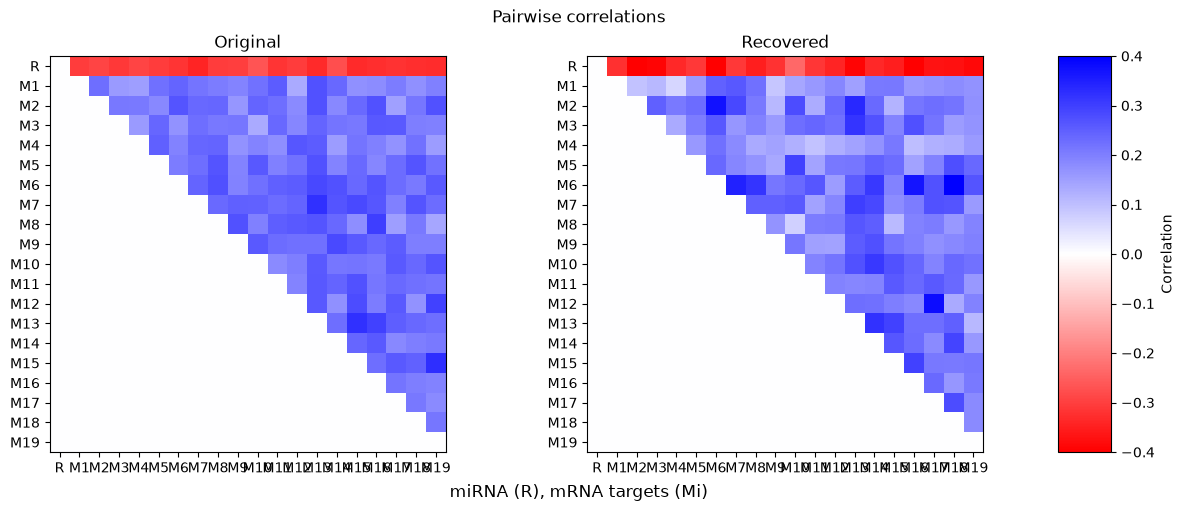

In [111]:
# select matrix
correlation_matrix_recovered = corr_dict[19]

# display
RNA_labels = ["R"] + [f"M{i + 1}" for i in range(targets)]
cmap = LinearSegmentedColormap.from_list('a', ['red', 'white', 'blue'])
fig, axs = plt.subplots(1, 3, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 1, 0.1]}, constrained_layout=True)
im = axs[0].imshow(correlation_matrix_original, cmap=cmap, vmin=-0.4, vmax=0.4)
im = axs[1].imshow(correlation_matrix_recovered, cmap=cmap, vmin=-0.4, vmax=0.4)
axs[0].set_title("Original")
axs[0].set_xticks(range(targets + 1))
axs[0].set_xticklabels(RNA_labels)
axs[0].set_yticks(range(targets + 1))
axs[0].set_yticklabels(RNA_labels)
axs[1].set_title("Recovered")
axs[1].set_xticks(range(targets + 1))
axs[1].set_xticklabels(RNA_labels)
axs[1].set_yticks(range(targets + 1))
axs[1].set_yticklabels(RNA_labels)
fig.suptitle("Pairwise correlations")
fig.supxlabel("miRNA (R), mRNA targets (Mi)")
plt.colorbar(im, cax=axs[2], label="Correlation")
plt.show()

# Optimization Scaling for Test Independent Data case

In [142]:
N = 1000
G = 100
counts = rng.poisson(2, size=(N, G))
beta = np.ones(N)

In [143]:
# construct dataset
data_SDP = SDP_miRNA.dataset.Dataset()

# duplicate full data (miRNA + mRNA) for easy indexing
data_SDP.construct_dataset_array(
    counts,
    counts,
    beta
)

In [154]:
# settings
G_list = [1, 2, 5, 10, 15, 20]
d = 3

# store results
times = []
cuts = []

for opt_G in G_list:

    # set gene queries
    gene_queries = [
        [[t for t in range(opt_G)], []]
    ]
    data_SDP.gene_queries = gene_queries
    data_SDP.total_gene_queries = len(gene_queries)

    # bootstrap
    data_SDP.bootstrap(d=d)

    # optimize
    BD_opt = GeneralBirthDeathOptimization(data_SDP, opt_G - 1, d=d)
    BD_opt.analyse_dataset()

    times.append(BD_opt.result_dict[0]['time'])
    cuts.append(BD_opt.result_dict[0]['cuts'])

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:36<00:00, 36.52s/it]


Text(0.5, 0.98, 'Optimization scaling with species')

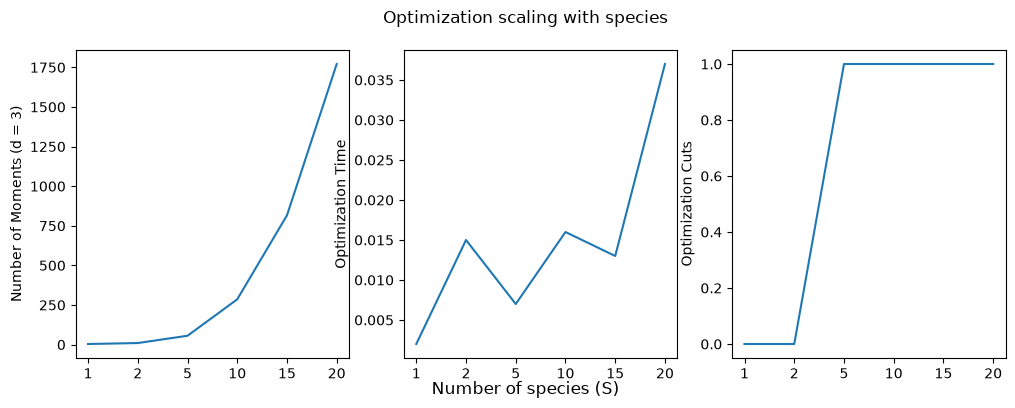

In [161]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
xs = range(len(G_list))
variables = [SDP_miRNA.utils.compute_Nd(opt_G, d) for opt_G in G_list]
axs[0].plot(xs, variables)
axs[0].set_ylabel("Number of Moments (d = 3)")
axs[0].set_xticks(xs)
axs[0].set_xticklabels(G_list)
axs[1].plot(xs, times)
axs[1].set_ylabel("Optimization Time")
axs[1].set_xticks(xs)
axs[1].set_xticklabels(G_list)
axs[2].plot(xs, cuts)
axs[2].set_ylabel("Optimization Cuts")
axs[2].set_xticks(xs)
axs[2].set_xticklabels(G_list)
fig.supxlabel("Number of species (S)")
fig.suptitle("Optimization scaling with species")

- strange because optimization times from GUROBI are small, but running time long
- could be semidefinite checks are slow?

In [164]:
BD_opt.eigenvalues_dict[0][-1]

{0: array([1.28223608e-02, 1.91422256e+00, 1.93163901e+00, 1.94849467e+00,
        1.95542909e+00, 1.97596686e+00, 1.98105410e+00, 1.98925556e+00,
        1.99656800e+00, 2.00870006e+00, 2.01354419e+00, 2.02032970e+00,
        2.02654127e+00, 2.04475893e+00, 2.05499209e+00, 2.06009041e+00,
        2.08730076e+00, 2.10200228e+00, 2.10655517e+00, 2.55880579e+00,
        8.43751156e+01]),
 1: array([1.22385635e-01, 3.15282699e+00, 3.24137812e+00, 3.43417631e+00,
        3.53888700e+00, 3.66962508e+00, 3.74464295e+00, 3.82762942e+00,
        3.90787452e+00, 3.94594743e+00, 4.13735491e+00, 4.19512954e+00,
        4.26378133e+00, 4.33209142e+00, 4.48698120e+00, 4.63226464e+00,
        4.70882240e+00, 4.88489825e+00, 5.06990343e+00, 6.60049140e+00,
        1.77973033e+02]),
 2: array([1.64124487e-01, 2.80470945e+00, 3.31943491e+00, 3.58542290e+00,
        3.71716232e+00, 3.85653277e+00, 3.90472716e+00, 4.01128937e+00,
        4.09054249e+00, 4.36840706e+00, 4.53200202e+00, 4.72773412e+00,
   